<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Exploratory Data Analysis and Visualisation

*Session 3 · Notebook 05 · Lecture · Student version*

## Overview

**Exploratory Data Analysis (EDA)** is how you get to know a dataset before any modelling: you summarise its structure, check its quality, and use plots to find patterns and relationships. It is the step that turns a raw table into understanding. In this notebook we work through a full EDA on the **Titanic passenger** dataset, building from single variables up to relationships between several.

## Learning Objectives

By the end of this notebook you will be able to:

- Describe what EDA is and follow a standard EDA workflow.
- Inspect a dataset and apply basic cleaning with the essential pandas functions.
- Analyse data at three levels: univariate, bivariate and multivariate.
- Choose and build appropriate visualisations with seaborn, following good-practice principles.

## Prerequisites

- Session 2 pandas (loading data, selecting, grouping, aggregating).
- Handling missing data and outliers in depth is covered separately in **03_01 Data Cleaning**; here we apply only basic cleaning and flag issues as we meet them.

## Index

- [Section 0: Setup](#setup)
- [Section 1: What is EDA?](#what)
- [Section 2: Essential pandas functions for EDA](#funcs)
- [Section 3: First look at the data](#first)
- [Section 4: Data quality and basic cleaning](#quality)
- [Section 5: Visualising the data](#viz)
- [Section 6: Univariate analysis](#uni)
- [Section 7: Bivariate analysis](#bi)
- [Section 8: Multivariate analysis](#multi)
- [Comparing plots on the same grid](#grid)
- [Challenge](#challenge)
- [Documenting your insights](#insights)
- [Key Takeaways](#takeaways)
- [Further Reading](#reading)

<a id="setup"></a>
# Section 0: Setup

We import the standard EDA stack and load the Titanic dataset from the project `datasets` folder, one level up from this notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import session_datasets

sns.set_theme(style='whitegrid')

##From S3:
titanic = pd.read_csv(session_datasets["train_titanic"])
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<a id="what"></a>
# Section 1: What is EDA?

EDA is the process of summarising a dataset's main characteristics, often visually, *before* formal modelling. Its goals are to:

- understand the **structure** of the data (rows, columns, types);
- assess **data quality** (missing values, errors, oddities);
- describe **distributions** of individual variables;
- uncover **relationships** between variables;
- form **hypotheses** worth testing later.

**Key questions to ask:**

- How big is the data, and what does each column mean?
- What types are the columns, and are they correct?
- Where are values missing, and why?
- How is each variable distributed? Are there extreme values?
- Which variables move together?

**A standard EDA workflow** (the spine of this notebook):

1. **Inspect** the data (shape, types, summary).
2. **Check quality** and apply basic cleaning.
3. **Univariate** analysis: one variable at a time.
4. **Bivariate** analysis: two variables together.
5. **Multivariate** analysis: three or more.
6. **Communicate** the insights.

The main tools in Python are **pandas** for summaries and **matplotlib** and **seaborn** for plots.

## Challenges in EDA

EDA is rarely just a technical exercise. Real projects run into three kinds of challenge:

**Strategic**
- What is the question, and what metrics define success?
- Does the work deliver valuable objectives, and how long and how much will it cost?
- Do we have permission, and is it legal, to access the data?

**Organisational**
- Is the data accessible, and do we have the means to reach it (cloud vs on-premises)?
- Where does the data actually live?

**Technical**
- Do conventions differ across datasets? Is data duplicated?
- Is the data formatted for analysis (for example numbers stored as text)?
- Do our tools give efficient access, and is there enough information (are the columns sufficient)?
- Do our tools save or forget data appropriately (for example Jupyter storing data in metadata)?

<a id="funcs"></a>
# Section 2: Essential pandas functions for EDA

Keep this table handy. Each function answers a specific question about the data.

| Function | What it tells you |
|---|---|
| `df.head()` / `df.tail()` | The first / last few rows |
| `df.shape` | Number of rows and columns |
| `df.info()` | Column names, types, and non-null counts |
| `df.dtypes` | The data type of each column |
| `df.describe()` | Summary statistics for numeric columns |
| `df.describe(include='object')` | Summary for text/categorical columns |
| `df['col'].value_counts()` | Frequency of each category |
| `df['col'].nunique()` / `.unique()` | Count / list of distinct values |
| `df.isnull().sum()` | Missing values per column |
| `df.duplicated().sum()` | Number of duplicate rows |
| `df.groupby('col').agg(...)` | Summaries per group |
| `df.corr(numeric_only=True)` | Correlation between numeric columns |

### Try it yourself: use the functions

Using the table above, find (a) how many duplicate rows the Titanic data has, and (b) how many distinct ticket numbers there are.

> *Hint: `.duplicated().sum()` and `titanic['Ticket'].nunique()`.*

In [37]:
# Your turn. Write your solution here:


<a id="first"></a>
# Section 3: First look at the data

Start every analysis the same way: how big is it, what are the columns, and what do the numbers look like?

(891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Summary of the numeric columns


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Summary of the text/categorical columns


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


### Try it yourself: inspect the categoricals

Show how many distinct values the `Embarked` column has, and the count of each.

> *Hint: `.nunique()` for the count of distinct values, `.value_counts()` for the breakdown.*

In [43]:
# Your turn. Write your solution here:


### Summarising with `groupby`

`groupby` (from Session 2) is one of the most useful EDA tools: it splits the data by a category and summarises each group, answering questions like "how does the average fare differ by class?" in a single line.

In [ ]:
# Average age and fare for each passenger class


,Age,Fare
Pclass,,
1,38.233441,84.154687
2,29.877630,20.662183
3,25.140620,13.675550


### Try it yourself: summarise by port

Using `groupby`, find the average `Fare` and the survival rate (`Survived`) for each port of embarkation (`Embarked`).

> *Hint: `titanic.groupby('Embarked')[['Fare', 'Survived']].mean()`.*

In [46]:
# Your turn. Write your solution here:


<a id="quality"></a>
# Section 4: Data quality and basic cleaning

EDA almost always surfaces quality problems, so a missing-value check belongs early. Watch out for **hidden** missing values too: placeholders like `0`, `-1`, `'Unknown'` or `'N/A'` that are really gaps in disguise.

In [ ]:
# Missing values per column


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# As a percentage, sorted from worst to best


Cabin          77.1
Age            19.9
Embarked        0.2
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
dtype: float64

So `Cabin` is mostly empty, `Age` has a meaningful chunk missing, and `Embarked` is almost complete.

### Try it yourself: the worst column

Which single column has the highest percentage of missing values?

> *Hint: Reuse the percentage calculation, then `.idxmax()` returns the column name.*

In [50]:
# Your turn. Write your solution here:


### Basic cleaning

A simple, common first pass is to **fill** the gaps: numeric columns with the column **mean**, and categorical columns with the **most frequent** value. (Deeper strategies, and when to *drop* a column like `Cabin` instead, are covered in **03_01 Data Cleaning**.)

In [ ]:
# Fill numeric columns with the mean


# Fill any remaining (categorical) columns with the most frequent value




PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

> **A caveat:** filling `Age` with the mean puts an artificial spike at the average age, which can distort a histogram. Because of that we keep exploring the **original** `titanic` below (seaborn handles missing values for us), but in a real pipeline you would carry a cleaned copy forward. Choosing the right fill strategy is itself part of cleaning (03_01).

<a id="viz"></a>
# Section 5: Visualising the data

If data is a story, visualisations are the illustrations: a good chart communicates in seconds what a table cannot.

### Two libraries: matplotlib and seaborn

Python's two main plotting libraries are **matplotlib** (powerful and low-level) and **seaborn** (built on top of matplotlib, producing attractive statistical charts in a single line). We will use **seaborn** for almost everything, dropping to matplotlib only for finishing touches (titles and axis labels) and for the pie chart, which seaborn does not provide.

### Visualisation best practices

1. **Choose the right chart type** for your data and question.
2. **Keep it simple**: avoid clutter and chart junk.
3. **Use colour purposefully**: highlight what matters.
4. **Label clearly**: titles, axes and legends.
5. **Consider your audience**: executives versus technical team.

### Choosing the right visualisation

The chart you pick depends on the **nature of the data** (categorical vs numeric), the **number of variables** (univariate, bivariate, multivariate), and your **objective** (compare, show a distribution, show a relationship, show composition).

| Your question | Chart | seaborn function |
|---|---|---|
| How is one numeric variable distributed? | Histogram / box / violin | `sns.histplot`, `sns.boxplot`, `sns.violinplot` |
| How frequent is each category? | Count / bar plot | `sns.countplot`, `sns.barplot` |
| What share of a whole is each category? | Pie chart (matplotlib) | `plt.pie` |
| How do two numeric variables relate? | Scatter plot | `sns.scatterplot` |
| How does a value change across an order? | Line plot | `sns.lineplot` |
| Does a numeric value differ by category? | Box / violin by group | `sns.boxplot`, `sns.violinplot` |
| How do many numeric variables correlate? | Heatmap / pair plot | `sns.heatmap`, `sns.pairplot` |

### Choosing the right chart


In [53]:
from IPython.display import display, HTML

image1_url = "https://media.licdn.com/dms/image/v2/D4D22AQEZb_EwP86WLA/feedshare-shrink_1280/B4DZQdRWcYHYAk-/0/1735657877159?e=2147483647&v=beta&t=FUVOHiNSNNpxAq9aEydUnXO4o9Nld1QqpQwcc39fJT0"

html_code = f"""
<div style="display: flex;">
  <img src="{image1_url}" style="margin-right: 10px;">
</div>
"""

display(HTML(html_code))

### Scenario: Who survived the Titanic, and why?

Imagine we are reviewing the 1912 Titanic disaster to understand which passengers were most likely to survive. For each passenger we have their class, sex, age, fare and whether they survived.

**Key questions we want the charts to answer:**

1. How are key variables like age and fare distributed?
2. Did survival differ by sex and by passenger class?
3. Do age and fare relate to each other, or to survival?
4. Which numeric variables move together?

<a id="uni"></a>
# Section 6: Univariate analysis

*Univariate* means one variable at a time. We describe each chart, then build it with seaborn.

### Histogram (`sns.histplot`)

A histogram splits a numeric variable into bins and shows how many values fall in each, revealing the **shape** of its distribution (symmetric, skewed, multi-peaked). Adding `kde=True` overlays a smoothed density curve, the 'bell', on top.

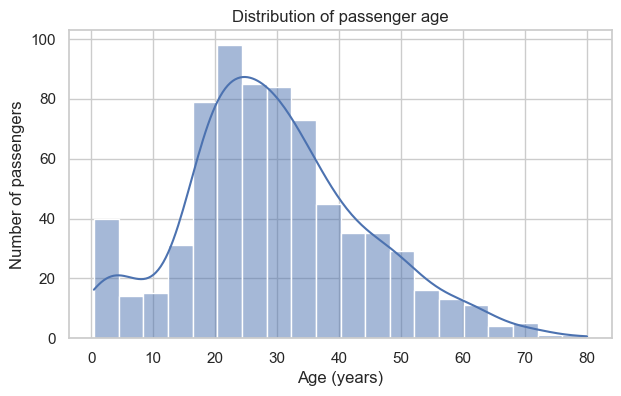

### Box plot (`sns.boxplot`)

A box plot summarises a numeric variable with its median, the middle 50% (the box) and the range (the whiskers). Points beyond the whiskers flag unusually high or low values.

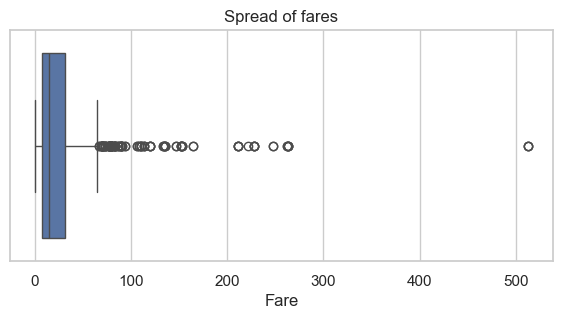

### Violin plot (`sns.violinplot`)

A violin plot is a box plot crossed with a density curve: its width shows where values are concentrated, so you see the full shape of the distribution, not just its summary.

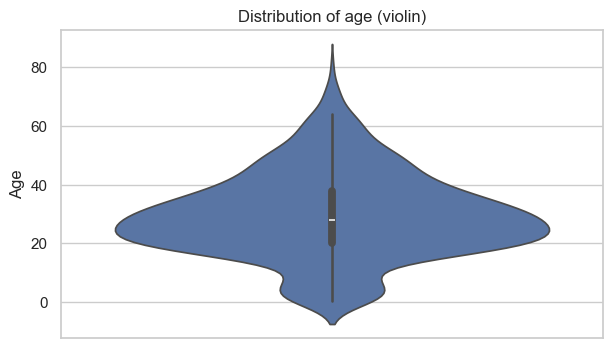

### Count plot (`sns.countplot`)

A count plot shows how many rows fall in each category of a categorical variable, the categorical equivalent of a histogram.

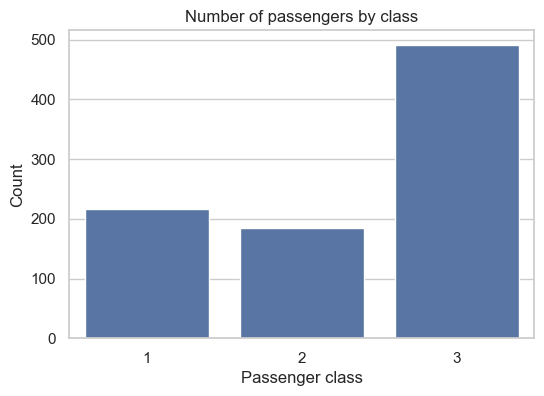

### Pie chart (`plt.pie`)

A pie chart shows parts of a whole as slices. It is easy to misread when slices are similar, so use it only for a few clearly different categories. Seaborn has no pie chart, so we drop to matplotlib.

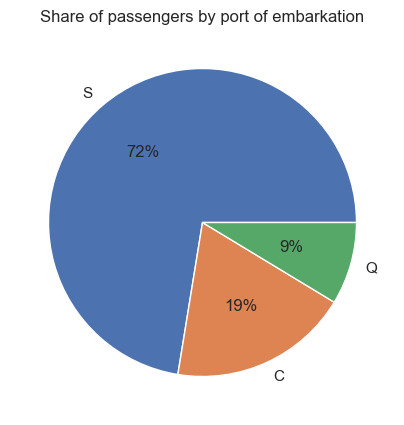

### Try it yourself: distribution of fare

Draw a histogram of `Fare` with a KDE curve, a title and axis labels.

> *Hint: `sns.histplot(data=titanic, x='Fare', kde=True)` then add labels.*

In [59]:
# Your turn. Write your solution here:


<a id="bi"></a>
# Section 7: Bivariate analysis

*Bivariate* means two variables together: does one relate to the other? On the Titanic, the natural target is **survival**.

### Scatter plot (`sns.scatterplot`)

A scatter plot places one numeric variable on each axis, with a point per row, revealing relationships, clusters and outliers. A `hue` colours the points by a third variable.

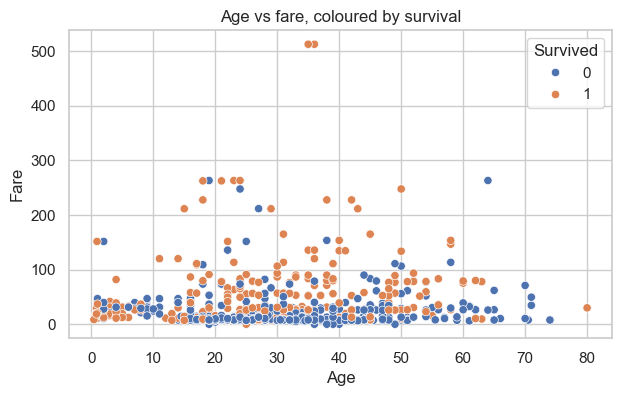

### Box plot by category (`sns.boxplot`)

Putting a category on one axis and a numeric variable on the other compares the distribution across groups, here fare across passenger classes.

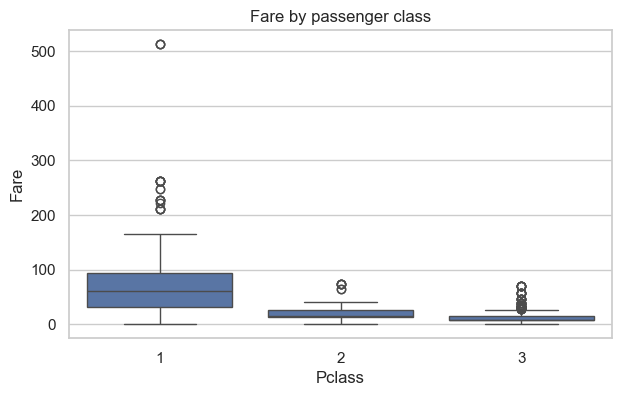

### Line plot (`sns.lineplot`)

A line plot connects points in order, ideal for showing how a value changes across an **ordered** variable such as time or, here, age band. We first group ages into bands, then plot the survival rate of each.

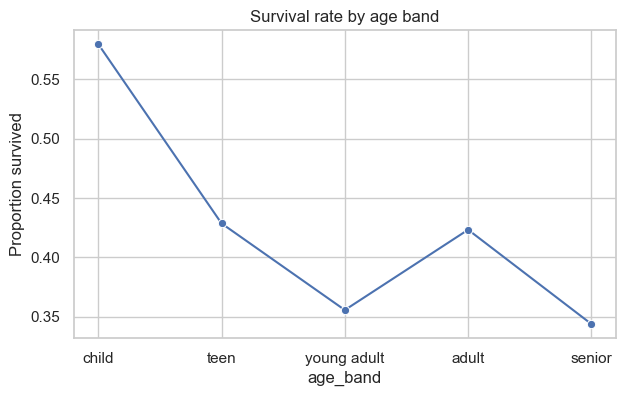

In [ ]:
titanic['age_band'] = pd.cut(
    titanic['Age'], bins=[0, 12, 18, 30, 50, 80],
    labels=['child', 'teen', 'young adult', 'adult', 'senior'])
by_band = titanic.groupby('age_band', observed=True)['Survived'].mean().reset_index()



### Try it yourself: survival by class

Compute and plot the survival rate for each passenger class (`Pclass`) as a bar chart.

> *Hint: `groupby('Pclass')['Survived'].mean()`, then `sns.barplot(...)`.*

In [64]:
# Your turn. Write your solution here:


<a id="multi"></a>
# Section 8: Multivariate analysis

*Multivariate* means three or more variables at once.

### Heatmap (`sns.heatmap`)

A heatmap colours a grid of numbers, here the **correlation** matrix, so strong relationships stand out at a glance. Correlation ranges from -1 to +1: near +1 the two variables rise together, near -1 one rises as the other falls, and near 0 there is little linear relationship.

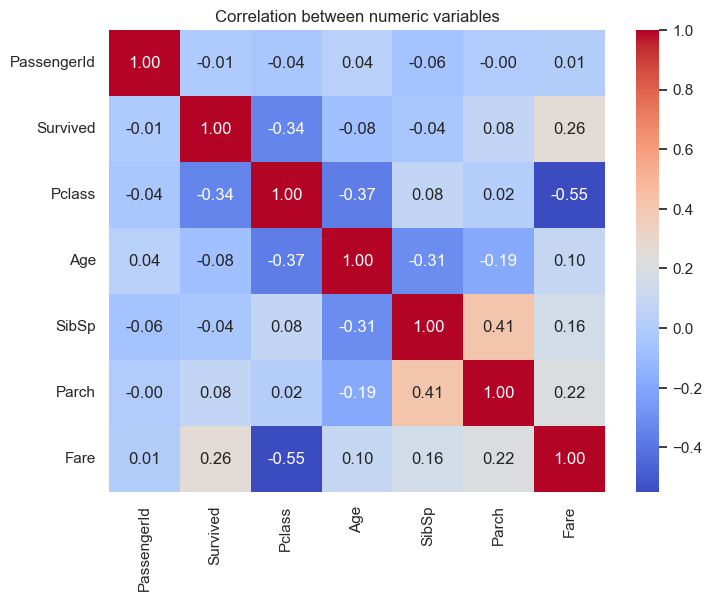

### Pair plot (`sns.pairplot`)

A pair plot draws a scatter for every pair of numeric variables and a distribution on the diagonal, a quick multivariate overview. We drop missing ages and colour by survival.

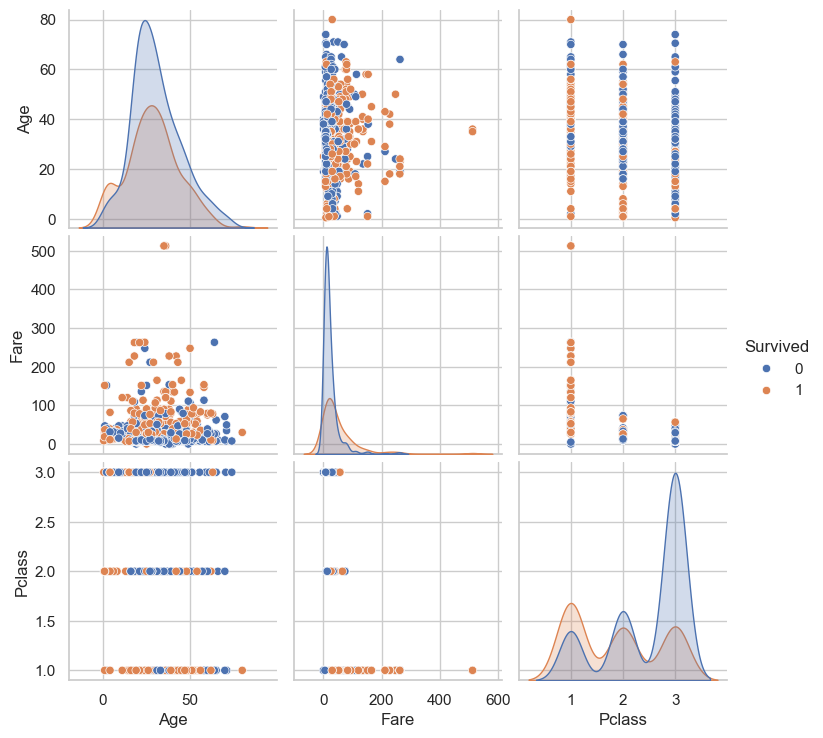

### Try it yourself: survival by sex and class

Build a table of the survival rate for every combination of `Sex` and `Pclass` (a 2-by-3 table).

> *Hint: Group by both columns, take the mean of `Survived`, then `.unstack()` to make a grid.*

In [68]:
# Your turn. Write your solution here:


<a id="grid"></a>
## Comparing plots on the same grid

Placing related charts side by side on one figure makes them easy to compare. `plt.subplots()` creates a grid of axes, and we tell each seaborn plot which axis to draw on with `ax=`.

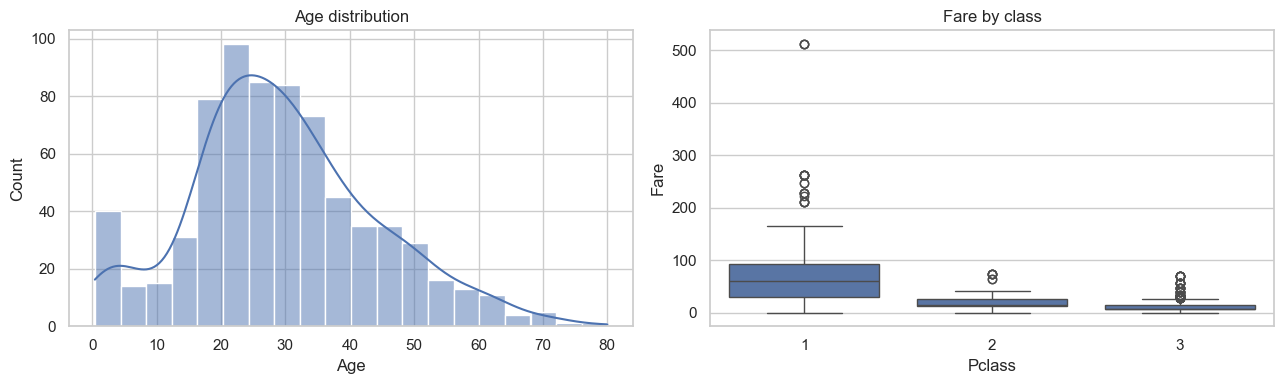

<a id="challenge"></a>
## Challenge: pick a chart from the seaborn gallery

### Challenge

Open the seaborn example gallery at <https://seaborn.pydata.org/examples/index.html> (or the API reference at <https://seaborn.pydata.org/api.html>). Choose a chart type we have **not** used in this notebook, apply it to the Titanic data, and add a comment explaining what it shows.

> *Hint: Good options to try: `sns.kdeplot`, `sns.swarmplot`, `sns.barplot`, `sns.regplot`. Call it with `data=titanic`.*

In [71]:
# Your turn. Write your solution here:


<a id="insights"></a>
## Documenting your insights

EDA is not finished when the last plot renders: it is finished when you have written down what you learned. For the Titanic data, for example:

- Survival was far higher for **women** than men, and for **first-class** passengers.
- **Fare** is highly skewed, with a few very expensive tickets.
- **Age** is missing for about a fifth of passengers, and **Cabin** for most.

A short written summary like this is the real output of EDA, and it guides whatever modelling comes next.

<a id="takeaways"></a>
## Key Takeaways

| Step | What you do |
|---|---|
| Inspect | `shape`, `info`, `describe`, `dtypes` |
| Check quality + clean | `isnull().sum()`, fill numeric with mean and categorical with mode |
| Univariate | histogram (+kde), box, violin, count, pie |
| Bivariate | scatter, box by group, line |
| Multivariate | correlation heatmap, pair plot |
| Communicate | compare on a grid, write down the insights |

And always: pick the chart for the question, use seaborn, and label every axis.

## Conclusion

You have run a full EDA on the Titanic data, from first look and basic cleaning to multivariate relationships. Next, practise on your own in the **03_02 EDA practical**. For automated first-pass profiling see **03_03 (ydata / sweetviz)**, and the statistics behind correlation and testing come in **Session 4**.

<a id="reading"></a>
## Further Reading and Resources

- [seaborn gallery](https://seaborn.pydata.org/examples/index.html) ideas and code for every chart.
- [seaborn API reference](https://seaborn.pydata.org/api.html).
- [pandas: visualisation](https://pandas.pydata.org/docs/user_guide/visualization.html).
- [GeeksforGeeks: steps for mastering EDA](https://www.geeksforgeeks.org/data-analysis/steps-for-mastering-exploratory-data-analysis-eda-steps/).